# Price Forecasting — Model Training
Change settings in the **Settings** cell, then run cells top-to-bottom.
Training scripts live in `src/models/` — this notebook just calls them and shows results.

In [1]:
# ── Settings ─────────────────────────────────────────────────────────────────
import sys, pandas as pd
from datetime import date, timedelta
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

# END_DATE: latest date retrievable from the TIGGE archive (48-hour embargo).
# Workers in cell-3 will download any missing dates up to this target.
# After merging, training features use all dates present in weather_ensemble.parquet.
END_DATE = (date.today() - timedelta(days=2)).isoformat()

# Validation splits — kept fixed so KPIs remain comparable across retraining runs.
# Advance these manually when you want to shift the evaluation window forward.
VAL_START_DEFAULT     = "2026-05-01"   # TRL Daily + TRE
VAL_START_TRL_WEEKLY  = "2026-04-06"   # TRL Weekly (needs more weeks at weekly resolution)

# Quantiles to train
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]

# TRE two-stage thresholds (CHF/MWh)
TRE_THRESHOLD_POS =  300.0   # above → extreme positive
TRE_THRESHOLD_NEG = -200.0   # below → extreme negative

print(f"  END_DATE (target): {END_DATE}  (today − 2 days, TIGGE embargo)")
print(f"  val_start default: {VAL_START_DEFAULT}")
print(f"  val_start weekly : {VAL_START_TRL_WEEKLY}")

  END_DATE (target): 2026-05-17  (today − 2 days, TIGGE embargo)
  val_start default: 2026-05-01
  val_start weekly : 2026-04-06


In [5]:
# ── Apply settings to config.yaml ────────────────────────────────────────────
import sys, subprocess, re, yaml
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

cfg_path = ROOT / "config" / "config.yaml"
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

cfg["training"]["end_date"]  = END_DATE
cfg["training"]["val_start"] = VAL_START_DEFAULT
cfg["training"]["quantiles"] = QUANTILES
cfg["models"]["trl_weekly"]["val_start"] = VAL_START_TRL_WEEKLY
cfg["models"]["tre"]["extreme_threshold_pos"] = TRE_THRESHOLD_POS
cfg["models"]["tre"]["extreme_threshold_neg"] = TRE_THRESHOLD_NEG

with open(cfg_path, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

print("Config updated:")
print(f"  end_date         : {END_DATE}")
print(f"  val_start        : {VAL_START_DEFAULT}  (TRL Weekly: {VAL_START_TRL_WEEKLY})")
print(f"  quantiles        : {QUANTILES}")
print(f"  TRE threshold pos: > {TRE_THRESHOLD_POS} CHF/MWh")
print(f"  TRE threshold neg: < {TRE_THRESHOLD_NEG} CHF/MWh")

Config updated:
  end_date         : 2026-05-17
  val_start        : 2026-05-01  (TRL Weekly: 2026-04-06)
  quantiles        : [0.1, 0.25, 0.5, 0.75, 0.9]
  TRE threshold pos: > 300.0 CHF/MWh
  TRE threshold neg: < -200.0 CHF/MWh


In [7]:
# ── ECMWF weather (background, ~2 min per new date) ──────────────────────────
# Launches background workers for any dates not yet downloaded.
# Check progress with the --status cell below; merge when done.
# Update END_DATE in Settings first if needed.
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/ecds_parallel_launch.py"), "--status"],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout)

subprocess.Popen(
     [sys.executable, str(ROOT / "src/data/ecds_parallel_launch.py"), "--workers", "2"],
     cwd=str(ROOT)
     )
print("Workers launched — re-run this cell to check status, then merge when done.")


subprocess.run([sys.executable, str(ROOT / "src/data/ecds_parallel_launch.py"), "--merge"],
               cwd=str(ROOT), capture_output=False)

Overall: 1598 / 1598 dates done (100.0%)

  main parquet : 1597 dates
  weather_ensemble_chunk_00.parquet: 1 dates  (2026-05-17 to 2026-05-17)

  ecds_chunk_00.log: 2026-05-19 15:50:50  INFO      Done.
  ecds_chunk_01.log: 2026-05-18 15:08:55  INFO      Done.
  ecds_chunk_02.log: 2026-05-09 18:03:57  INFO      Done.
  ecds_chunk_03.log: 2026-05-09 15:32:20  INFO      Done.
  ecds_chunk_04.log: 2026-05-09 05:19:52  INFO      Done.
  ecds_chunk_05.log: 2026-05-06 10:04:51  INFO      Done.

Workers launched — re-run this cell to check status, then merge when done.


CompletedProcess(args=['c:\\Users\\ThijsAntoniedeBoer\\OneDrive - HELION\\Dokumente\\python-projects\\standard_env\\Scripts\\python.exe', 'C:\\Users\\ThijsAntoniedeBoer\\OneDrive - HELION\\Dokumente\\Price Forecasting\\src\\data\\ecds_parallel_launch.py', '--merge'], returncode=0)

In [8]:
# ── TRE prices (Swissgrid) ────────────────────────────────────────────────────
import subprocess, sys
from pathlib import Path
ROOT = Path().resolve().parent
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/update_tre_prices.py")],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr[-500:])

Found 5 TRE file(s) on Swissgrid:
  2026-01-TRE-Ergebnis.csv
  2026-02-TRE-Ergebnis.csv
  2026-03-TRE-Ergebnis.csv
  2026-04-TRE-Ergebnis.csv.zip
  2026-05-TRE-Ergebnis.csv.zip
  Skipping 2026-01-TRE-Ergebnis.csv (already in parquet)
  Skipping 2026-02-TRE-Ergebnis.csv (already in parquet)
  Skipping 2026-03-TRE-Ergebnis.csv (already in parquet)
  Skipping 2026-04-TRE-Ergebnis.csv.zip (already in parquet)

Saved 235352 rows to tre_slots.parquet
Latest slot: 2026-05-17 21:45:00+00:00



In [9]:
# ── Spot prices + TRL Weekly/Daily + reservoir levels (from Helion dashboard) ─
import sys, re, subprocess
from pathlib import Path
import pandas as pd

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.data.market_data import fetch_data, parse_spot_hourly, parse_trl_weekly, parse_trl_daily, parse_reservoir_levels

data = fetch_data()
PRICES_DIR = ROOT / "data" / "raw" / "prices"
MARKET_DIR = ROOT / "data" / "raw" / "market"

for name, df in [
    ("spot_hourly", parse_spot_hourly(data)),
    ("trl_weekly",  parse_trl_weekly(data)),
    ("trl_daily",   parse_trl_daily(data)),
]:
    path = PRICES_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"  {name}: {len(df)} rows, latest {df.iloc[-1, 0]}")

res = parse_reservoir_levels()
res.to_parquet(MARKET_DIR / "reservoir_levels.parquet", index=False)
print(f"  reservoir_levels: {len(res)} rows, latest {res['date'].max()}")

  spot_hourly: 38424 rows, latest 2026-05-20 21:00:00+00:00
  trl_weekly: 484 rows, latest 2026-05-25 00:00:00
  trl_daily: 18834 rows, latest 2026-05-20 18:00:00+00:00
  reservoir_levels: 1376 rows, latest 2026-05-11 00:00:00


---
## Data update
Run before retraining to pull the latest prices and weather.
Run cells in order — Rebuild features must come after all source data is updated.

| Step | Cell | Source | Speed |
|---|---|---|---|
| ECMWF weather | 3 | ECDS archive | ~2 min/date, background |
| TRE prices | 4 | Swissgrid tenders page | ~30s |
| Spot + TRL + reservoir | 5 | Helion dashboard (GitHub) | ~5s |
| Rebuild features | 6 | local computation | ~15s |

In [10]:
# ── Rebuild features ─────────────────────────────────────────────────────────
result = subprocess.run(
    [sys.executable, str(ROOT / "src/data/feature_store.py")],
    capture_output=True, text=True, cwd=str(ROOT)
)
clean = "\n".join(
    re.sub(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d+\s+\w+\s+', '', l)
    for l in (result.stdout + result.stderr).splitlines()
)
print(clean if clean.strip() else "Done.")
if result.returncode != 0:
    print("ERROR:", result.stderr[-500:])

Building TRL Weekly features ...
Saved 484 rows â†’ trl_weekly_features.parquet
Building TRL Daily features ...
Saved 18834 rows â†’ trl_daily_features.parquet
Building TRE features ...
Saved 235352 rows â†’ tre_features.parquet
Done.


---
## Train models
Run individually or all at once. Output shows pinball loss per quantile.

In [11]:
import subprocess, re

_LOG_PREFIX = re.compile(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d+\s+\w+\s+')

def run_script(script: str) -> tuple[str, list[dict]]:
    """Run a training script, stream output, return (stdout, parsed pinball rows)."""
    result = subprocess.run(
        [sys.executable, str(ROOT / script)],
        capture_output=True, text=True, cwd=str(ROOT)
    )
    out = result.stdout + result.stderr
    clean = "\n".join(_LOG_PREFIX.sub("", l) for l in out.splitlines())
    print(clean)
    # Parse pinball lines — two formats:
    #   new (TRL Weekly): "q=0.10  n_est=142  pinball_es=...  pinball_kpi=17.19"
    #   old (TRL Daily / TRE): "q=0.10  pinball=4.03  best_iter=69"
    rows = []
    for line in out.splitlines():
        m = re.search(r'\[(\w+)/(\w+)\]', line)
        if m:
            cur_dir = m.group(2)
        m2 = re.search(r'q=(\d\.\d+).*pinball_kpi=([\d\.]+)', line)
        if not m2:
            m2 = re.search(r'q=(\d\.\d+)\s+pinball=([\d\.]+)', line)
        if m2:
            rows.append({"direction": cur_dir,
                         "q": float(m2.group(1)),
                         "pinball": float(m2.group(2))})
    return out, rows

In [12]:
print("=" * 60)
print("TRL Weekly")
print("=" * 60)
_, rows_weekly = run_script("src/models/trl_weekly_model.py")

TRL Weekly
[trl_weekly/up] train=118  es_val=63  kpi_val=8
q=0.10  CV best_iters=[23, 15, 28]  â†’ n_estimators=30
q=0.10  n_est=30  pinball_es=20.6763  pinball_kpi=25.4508
q=0.25  CV best_iters=[1, 33, 300]  â†’ n_estimators=133
q=0.25  n_est=133  pinball_es=24.6150  pinball_kpi=25.5840
q=0.50  CV best_iters=[16, 67, 183]  â†’ n_estimators=106
q=0.50  n_est=106  pinball_es=43.6744  pinball_kpi=34.0783
q=0.75  CV best_iters=[60, 57, 89]  â†’ n_estimators=82
q=0.75  n_est=82  pinball_es=47.2451  pinball_kpi=36.5608
q=0.90  CV best_iters=[5, 57, 120]  â†’ n_estimators=72
q=0.90  n_est=72  pinball_es=46.1004  pinball_kpi=37.1861
Saved â†’ trl_weekly_up.pkl
[trl_weekly/down] train=118  es_val=63  kpi_val=8
q=0.10  CV best_iters=[4, 3, 9]  â†’ n_estimators=30
q=0.10  n_est=30  pinball_es=181.3517  pinball_kpi=79.3278
q=0.25  CV best_iters=[28, 27, 76]  â†’ n_estimators=52
q=0.25  n_est=52  pinball_es=285.5511  pinball_kpi=127.0595
q=0.50  CV best_iters=[251, 142, 149]  â†’ n_estimators=216


In [13]:
print("=" * 60)
print("TRL Daily")
print("=" * 60)
_, rows_daily = run_script("src/models/trl_daily_model.py")

TRL Daily
[trl_daily/up] train=5196  val=119
q=0.10  pinball=1.0689  best_iter=90
q=0.25  pinball=2.2642  best_iter=117
q=0.50  pinball=3.7443  best_iter=79
q=0.75  pinball=4.4818  best_iter=130
q=0.90  pinball=4.6055  best_iter=84
Saved â†’ trl_daily_up.pkl
[trl_daily/down] train=4859  val=116
q=0.10  pinball=5.1694  best_iter=153
q=0.25  pinball=9.6101  best_iter=111
q=0.50  pinball=17.1646  best_iter=180
q=0.75  pinball=16.5219  best_iter=195
q=0.90  pinball=13.2094  best_iter=200
Saved â†’ trl_daily_down.pkl

direction  quantile   pinball
       up      0.10  1.068925
       up      0.25  2.264205
       up      0.50  3.744283
       up      0.75  4.481832
       up      0.90  4.605452
     down      0.10  5.169381
     down      0.25  9.610095
     down      0.50 17.164583
     down      0.75 16.521879
     down      0.90 13.209426


In [14]:
print("=" * 60)
print("TRE (two-stage)")
print("=" * 60)
_, rows_tre = run_script("src/models/tre_model.py")

TRE (two-stage)
[tre/pos] train=115916 (extreme=1709, 1.5%)  val=1624 (extreme=19, 1.2%)
Classifier  AUC=0.9782  best_iter=1
Normal  train=114207 val=1605  |  Extreme  train=1709 val=19
q=0.10  pinball=12.1277
q=0.25  pinball=23.5246
q=0.50  pinball=41.1699
q=0.75  pinball=39.9410
q=0.90  pinball=32.4448
Saved -> tre_pos.pkl
[tre/neg] train=115916 (extreme=2589, 2.2%)  val=1624 (extreme=11, 0.7%)
Classifier  AUC=0.9597  best_iter=1
Normal  train=113327 val=1613  |  Extreme  train=2589 val=11
q=0.10  pinball=7.7700
q=0.25  pinball=14.5045
q=0.50  pinball=21.7155
q=0.75  pinball=19.2154
q=0.90  pinball=11.6102
Saved -> tre_neg.pkl

direction  quantile   pinball
      pos      0.10 12.127704
      pos      0.25 23.524574
      pos      0.50 41.169859
      pos      0.75 39.941014
      pos      0.90 32.444838
      neg      0.10  7.769986
      neg      0.25 14.504454
      neg      0.50 21.715480
      neg      0.75 19.215353
      neg      0.90 11.610173


---
## Results — Pinball loss on validation set

In [15]:
import pandas as pd

def pinball_table(rows, model_name):
    if not rows:
        print(f"{model_name}: no results parsed")
        return
    df = pd.DataFrame(rows)
    pt = df.pivot(index="direction", columns="q", values="pinball").round(2)
    pt.columns = [f"q{c:.2f}" for c in pt.columns]
    print(f"\n{'─'*50}")
    print(f"  {model_name}  — pinball loss (val set, CHF/MWh or CHF/MW)")
    print(f"{'─'*50}")
    display(pt)

pinball_table(rows_weekly, "TRL Weekly")
pinball_table(rows_daily,  "TRL Daily")
pinball_table(rows_tre,    "TRE (two-stage)")


──────────────────────────────────────────────────
  TRL Weekly  — pinball loss (val set, CHF/MWh or CHF/MW)
──────────────────────────────────────────────────


,q0.10,q0.25,q0.50,q0.75,q0.90
direction,,,,,
down,79.33,127.06,239.70,448.21,297.21
up,25.45,25.58,34.08,36.56,37.19



──────────────────────────────────────────────────
  TRL Daily  — pinball loss (val set, CHF/MWh or CHF/MW)
──────────────────────────────────────────────────


,q0.10,q0.25,q0.50,q0.75,q0.90
direction,,,,,
down,5.17,9.61,17.16,16.52,13.21
up,1.07,2.26,3.74,4.48,4.61



──────────────────────────────────────────────────
  TRE (two-stage)  — pinball loss (val set, CHF/MWh or CHF/MW)
──────────────────────────────────────────────────


,q0.10,q0.25,q0.50,q0.75,q0.90
direction,,,,,
neg,7.77,14.50,21.72,19.22,11.61
pos,12.13,23.52,41.17,39.94,32.44


---
## Revenue Backtest (pay-as-bid)
All three markets use pay-as-bid clearing — you earn your own bid price, not the clearing price.

**Optimal bid:** for each slot, pick the quantile `q` that maximises expected profit:
- Positive-price markets: `(price[q] − opp_cost) × (1 − q)` — higher q = more profit per MW but lower selection probability
- TRE neg: `(|price[q]| − 200) × q` — uses the extreme-regime model (prices conditional on clearing < −200 CHF/MWh)

**Columns:** `opt_select_%` = fraction of val-set slots where our bid was accepted · `capture_%` = our P&L ÷ oracle P&L (oracle knows the clearing price in advance)

In [16]:
# ── Revenue backtest (pay-as-bid) ─────────────────────────────────────────────
import sys, yaml, importlib, json
from pathlib import Path
import pandas as pd
from datetime import datetime

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import src.pipeline.bid_strategy    as bs
import src.models.trl_weekly_model  as _m_w
import src.models.trl_daily_model   as _m_d
import src.models.tre_model         as _m_t
for _mod in (bs, _m_w, _m_d, _m_t):
    importlib.reload(_mod)

FC_W = _m_w.FEATURE_COLS
FC_D = _m_d.FEATURE_COLS
FC_T = _m_t.FEATURE_COLS

with open(ROOT / "config" / "config.yaml") as f:
    cfg = yaml.safe_load(f)

quantiles   = cfg["training"]["quantiles"]
val_default = cfg["training"]["val_start"]
val_weekly  = cfg["models"]["trl_weekly"].get("val_start") or val_default
tre_neg_opp = abs(cfg["models"]["tre"]["extreme_threshold_neg"])  # 200 CHF/MWh

FP = ROOT / "data/processed/features"
MP = ROOT / "models"

CASES = [
    dict(label="TRL Weekly  up",   fp=FP/"trl_weekly_features.parquet", tc="week_start",  d="up",   fc=FC_W, mp=MP/"trl_weekly/trl_weekly_up.pkl",   vs=val_weekly,  mode="pos_market", oc=0.0),
    dict(label="TRL Weekly  down", fp=FP/"trl_weekly_features.parquet", tc="week_start",  d="down", fc=FC_W, mp=MP/"trl_weekly/trl_weekly_down.pkl", vs=val_weekly,  mode="pos_market", oc=0.0),
    dict(label="TRL Daily   up",   fp=FP/"trl_daily_features.parquet",  tc="block_start", d="up",   fc=FC_D, mp=MP/"trl_daily/trl_daily_up.pkl",     vs=val_default, mode="pos_market", oc=0.0),
    dict(label="TRL Daily   down", fp=FP/"trl_daily_features.parquet",  tc="block_start", d="down", fc=FC_D, mp=MP/"trl_daily/trl_daily_down.pkl",   vs=val_default, mode="pos_market", oc=0.0),
    dict(label="TRE         pos",  fp=FP/"tre_features.parquet",        tc="slot_time",   d="pos",  fc=FC_T, mp=MP/"tre/tre_pos.pkl",                vs=val_default, mode="pos_market", oc=0.0),
    dict(label="TRE         neg",  fp=FP/"tre_features.parquet",        tc="slot_time",   d="neg",  fc=FC_T, mp=MP/"tre/tre_neg.pkl",                vs=val_default, mode="neg_market", oc=tre_neg_opp),
]

rows = []
for c in CASES:
    res = bs.run_backtest(
        features_parquet=c["fp"], time_col=c["tc"], direction=c["d"],
        feature_cols=c["fc"],     model_pkl=c["mp"], quantiles=quantiles,
        val_start=c["vs"],        opp_cost=c["oc"],  mode=c["mode"],
    )
    if res.empty:
        rows.append({"market": c["label"], "slots": 0})
        continue
    oracle_sum = res["oracle_pnl_chf"].sum()
    rows.append({
        "market":          c["label"],
        "slots":           len(res),
        "opt_select_%":    round(res["selected"].mean()        * 100, 1),
        "med_select_%":    round(res["median_selected"].mean() * 100, 1),
        "opt_pnl/slot":    round(res["pnl_chf"].mean(),         2),
        "med_pnl/slot":    round(res["median_pnl_chf"].mean(),  2),
        "oracle_pnl/slot": round(res["oracle_pnl_chf"].mean(),  2),
        "capture_%":       round(res["pnl_chf"].sum() / oracle_sum * 100, 1) if oracle_sum > 0 else float("nan"),
    })

print("Pay-as-bid revenue backtest — val set  (CHF per MW-slot, capacity = 1 MW)")
print("  opt_select_%  : fraction of slots our optimal bid was accepted")
print("  capture_%     : our P&L / oracle P&L  (oracle = perfect-foresight bid)\n")
display(pd.DataFrame(rows).set_index("market"))

# Save results — timestamped file preserves every run; latest file is the /log shortcut
_ts = datetime.now().strftime("%Y%m%d_%H%M%S")
_payload = {"timestamp": _ts, "results": rows}
_runs_dir = ROOT / "data" / "processed" / "backtest_runs"
_runs_dir.mkdir(exist_ok=True)
(_runs_dir / f"backtest_{_ts}.json").write_text(json.dumps(_payload, indent=2))
(ROOT / "data" / "processed" / "backtest_latest.json").write_text(json.dumps(_payload, indent=2))
print(f"\nResults saved → backtest_runs/backtest_{_ts}.json  +  backtest_latest.json")

Pay-as-bid revenue backtest — val set  (CHF per MW-slot, capacity = 1 MW)
  opt_select_%  : fraction of slots our optimal bid was accepted
  capture_%     : our P&L / oracle P&L  (oracle = perfect-foresight bid)



,slots,opt_select_%,med_select_%,opt_pnl/slot,med_pnl/slot,oracle_pnl/slot,capture_%
market,,,,,,,
TRL Weekly up,7,100.0,71.4,481.33,375.31,573.67,83.9
TRL Weekly down,7,14.3,14.3,209.93,209.93,1089.39,19.3
TRL Daily up,113,47.8,29.2,4.54,3.67,13.84,32.8
TRL Daily down,111,34.2,23.4,31.89,29.64,68.97,46.2
TRE pos,1624,23.8,40.6,28.97,24.95,84.34,34.4
TRE neg,1624,0.6,0.3,0.61,0.35,0.83,73.5



Results saved → backtest_runs/backtest_20260519_155320.json  +  backtest_latest.json


---
## SHAP Feature Importance
Run `notebooks/04_shap_importance.py` first to regenerate plots after training.

In [17]:
print("Generating SHAP plots ...")
run_script("notebooks/04_shap_importance.py")
print("Done.")

Generating SHAP plots ...
TRL Weekly ...
Saved -> shap_trl_weekly.png
TRL Daily ...
Saved -> shap_trl_daily.png
TRE ...
Saved -> shap_tre_normal.png
Saved -> shap_tre_classifier.png
Done. Figures saved to notebooks/figures/
  shap_tre_normal.png    â€” normal-regime quantile model (q=0.50)
  shap_tre_classifier.png â€” classifier: what drives P(extreme price)
Done.



TRL Weekly


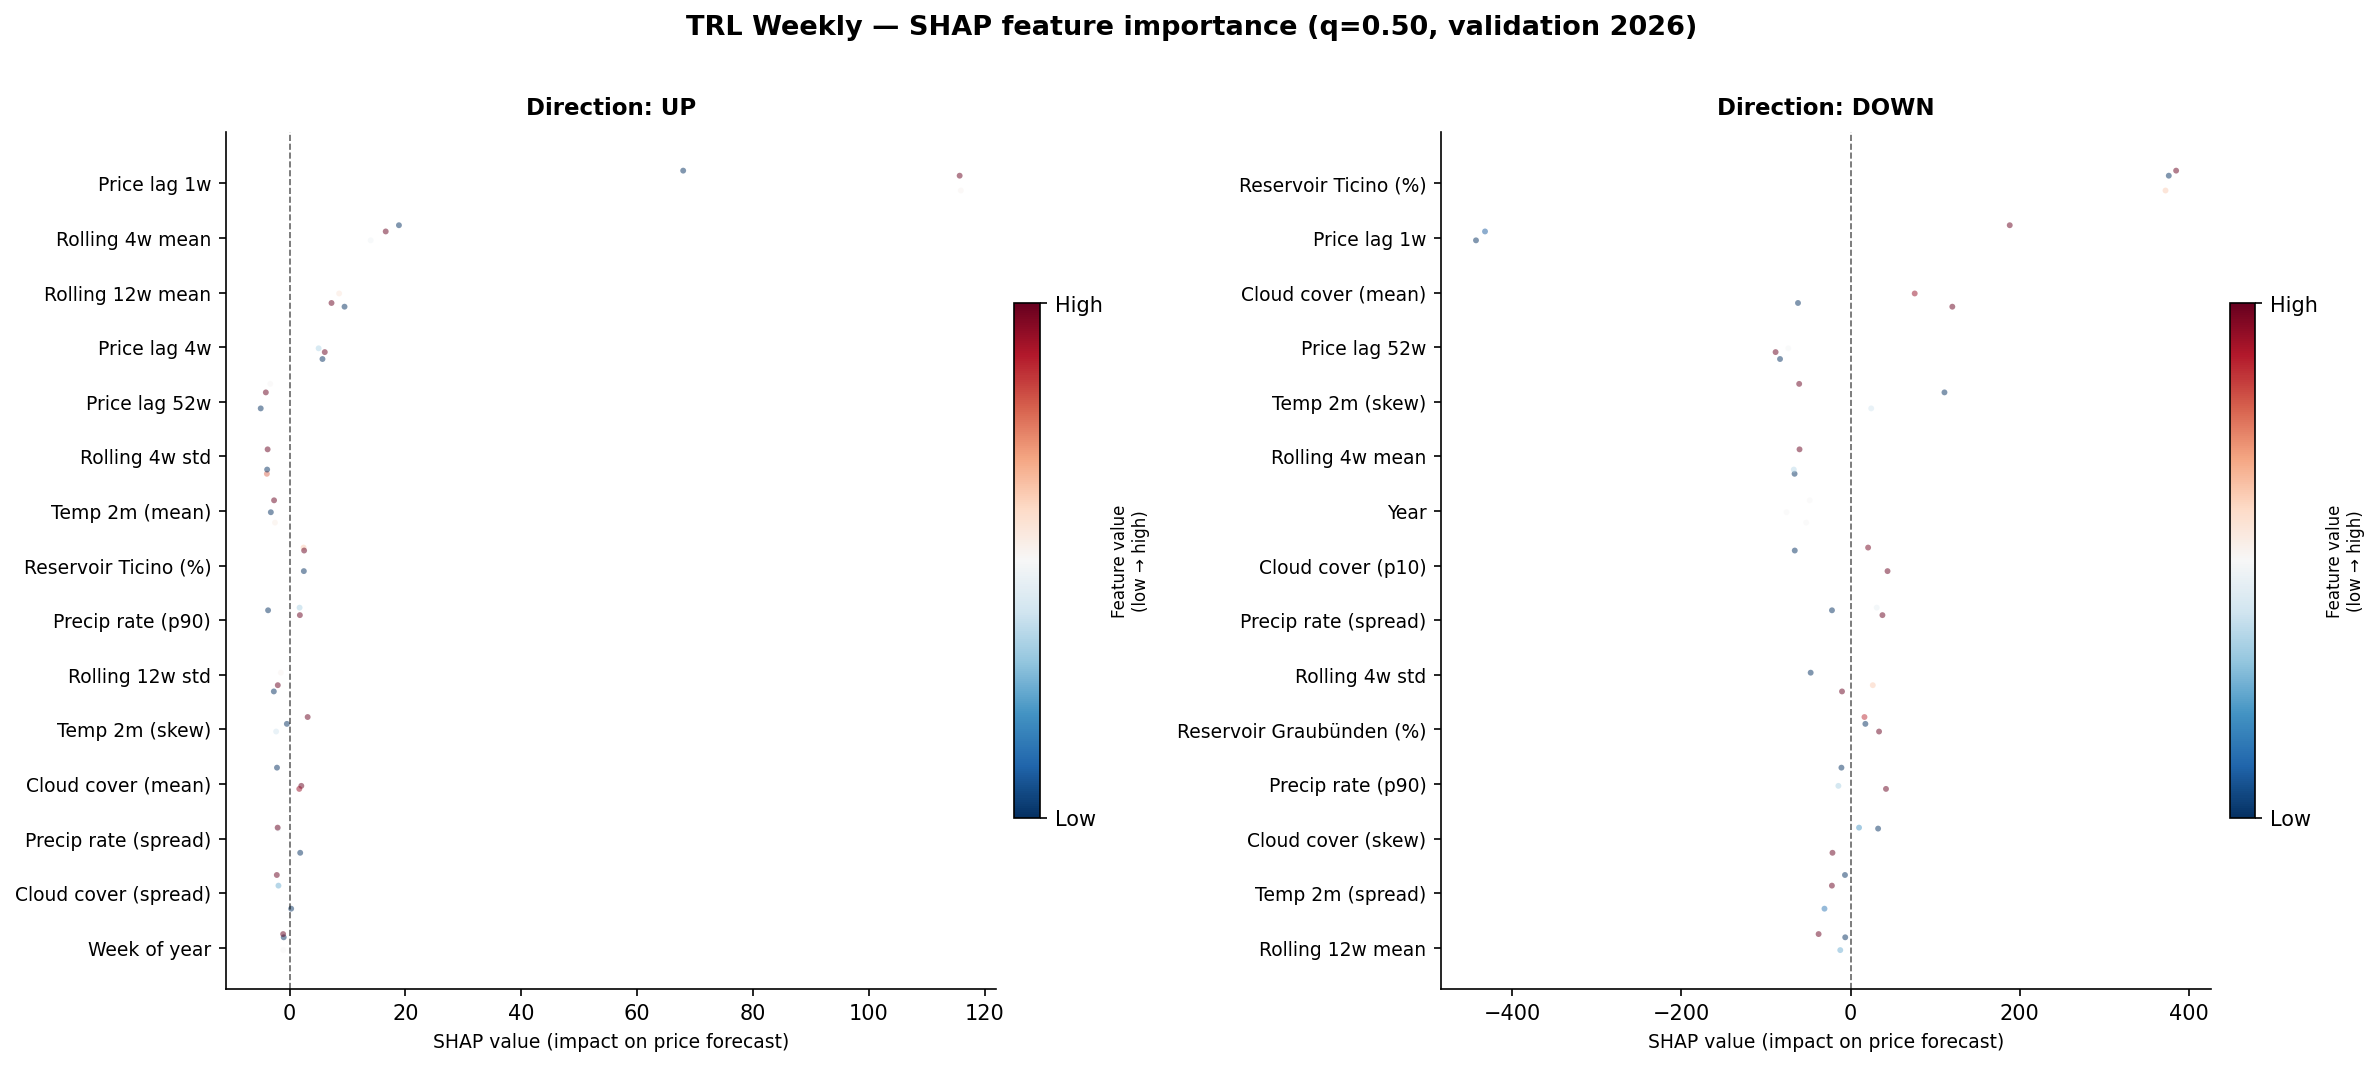


TRL Daily


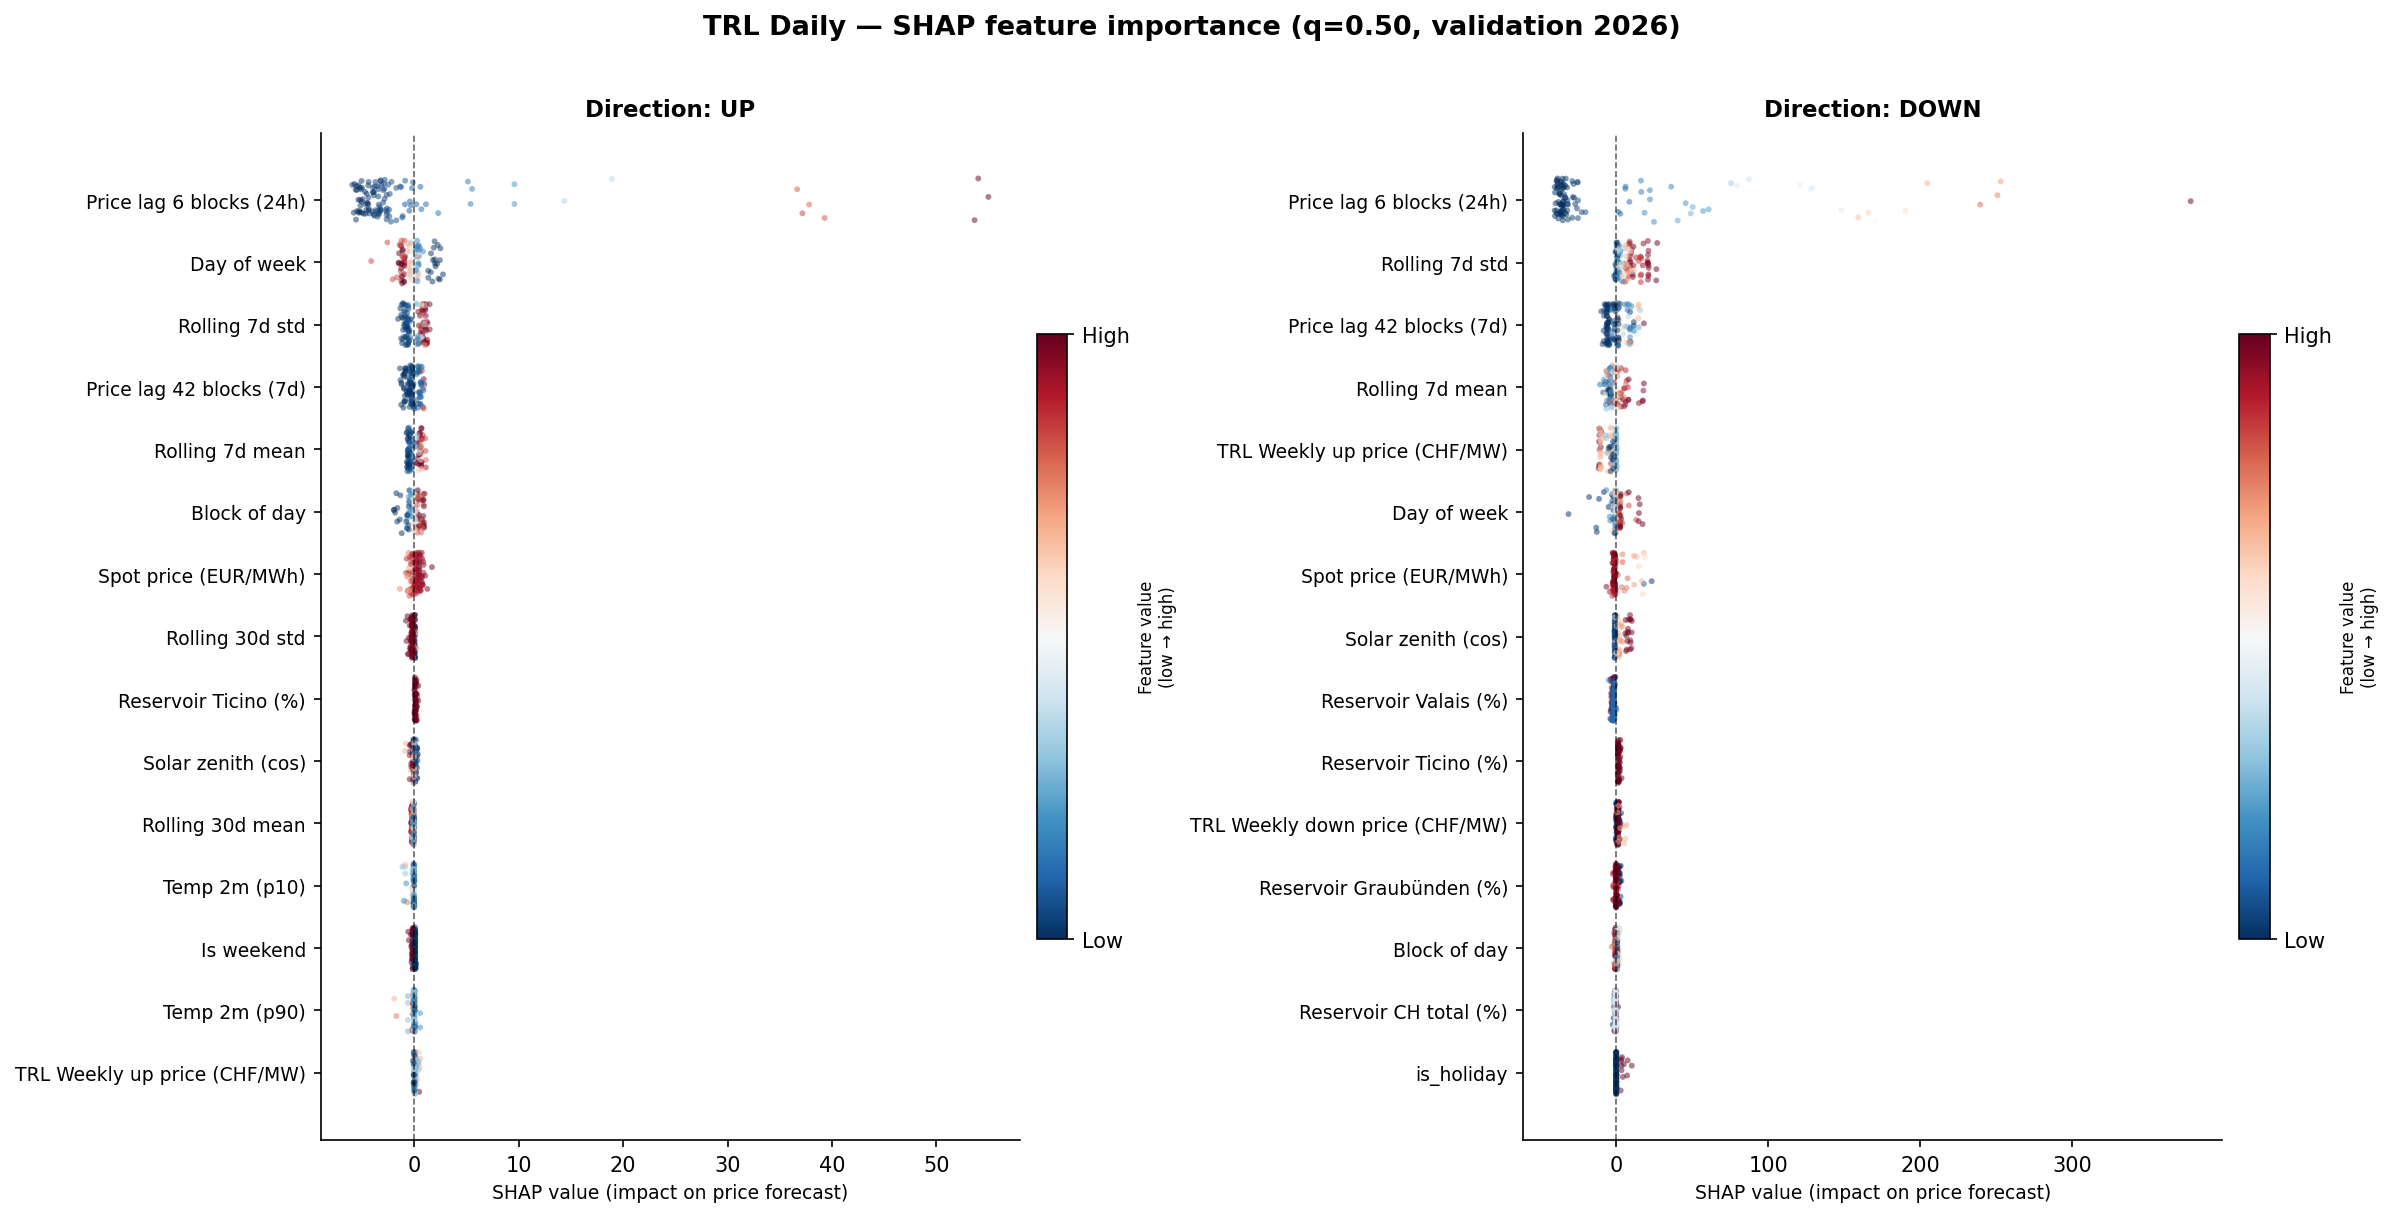


TRE — Normal regime (q=0.50)


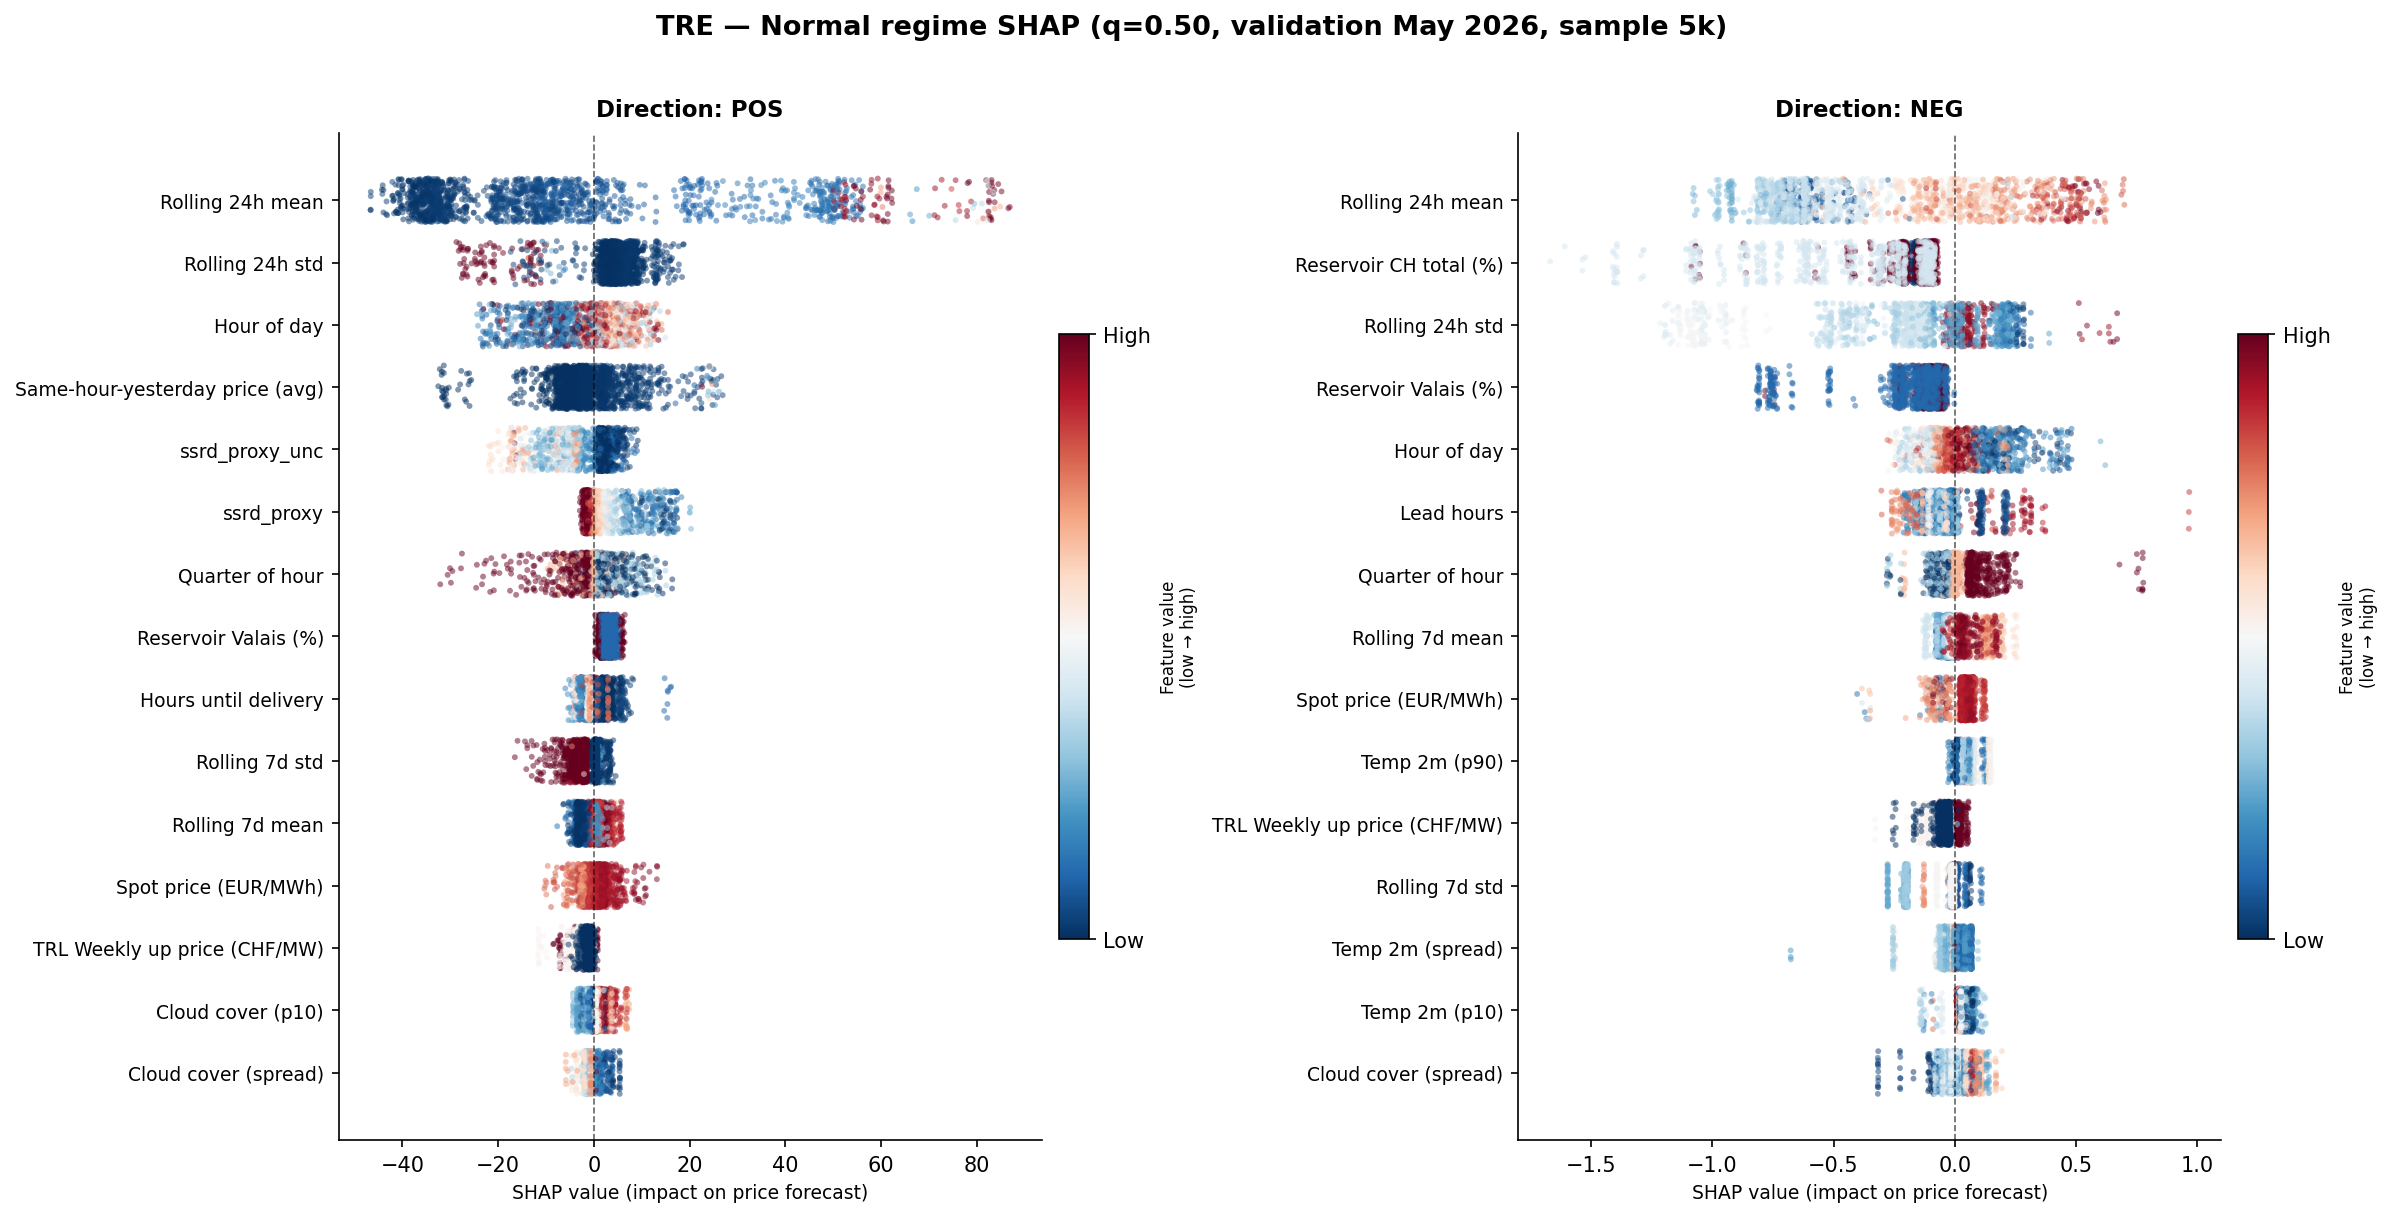


TRE — Classifier P(extreme)


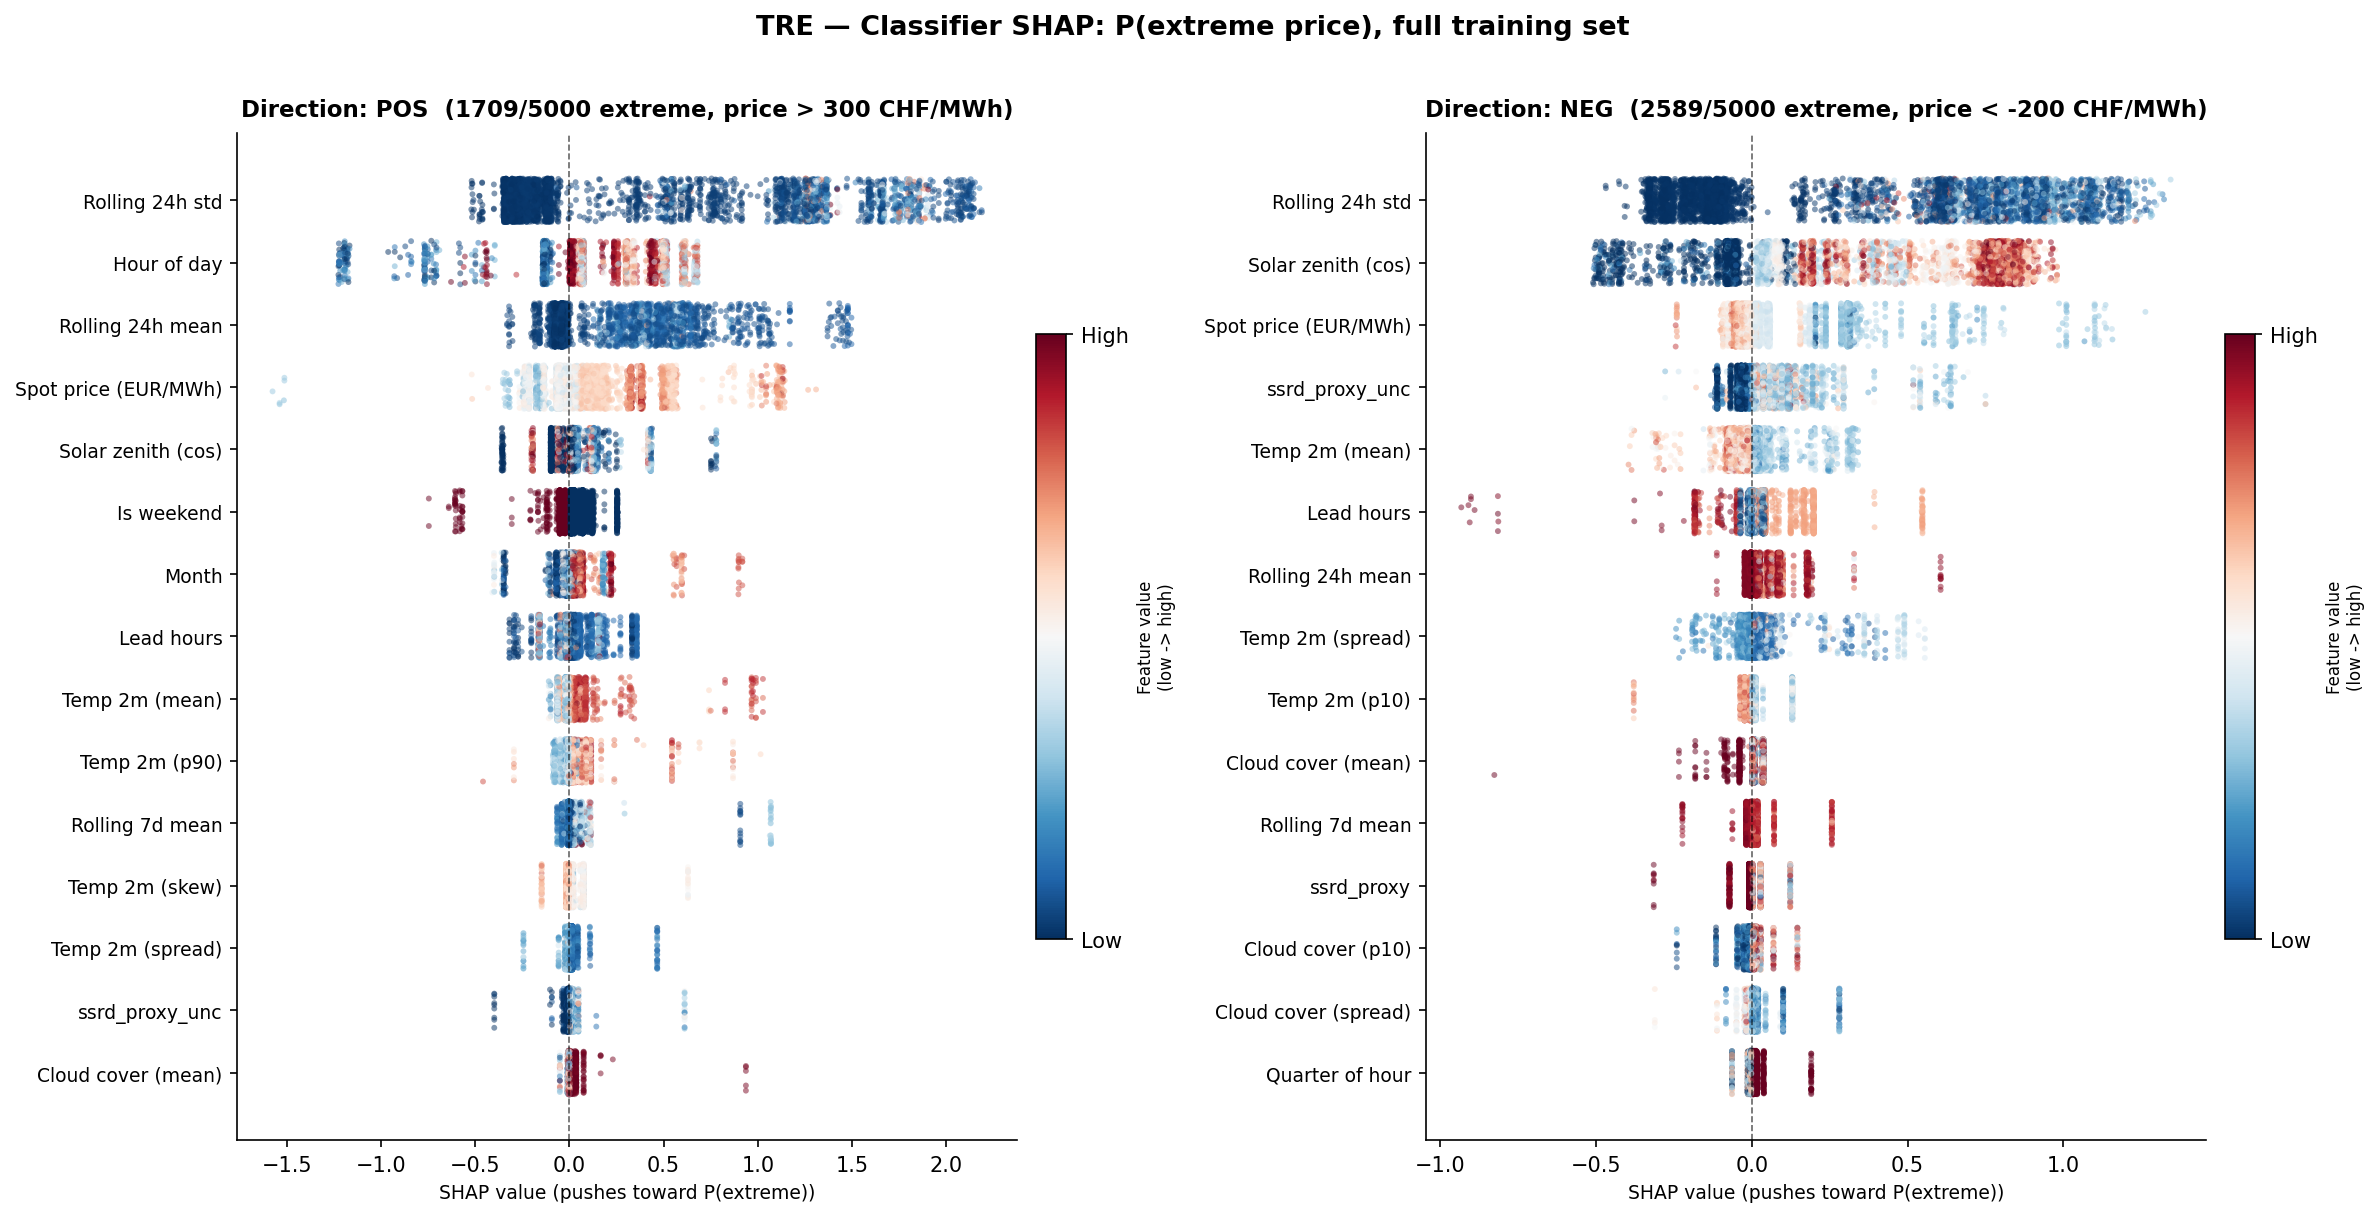

In [18]:
from IPython.display import Image, display as ipy_display

figures = ROOT / "notebooks" / "figures"

for title, fname in [
    ("TRL Weekly",                   "shap_trl_weekly.png"),
    ("TRL Daily",                    "shap_trl_daily.png"),
    ("TRE — Normal regime (q=0.50)", "shap_tre_normal.png"),
    ("TRE — Classifier P(extreme)",  "shap_tre_classifier.png"),
]:
    path = figures / fname
    if path.exists():
        print(f"\n{title}")
        ipy_display(Image(str(path)))
    else:
        print(f"Missing: {fname}")